# Multi-class topic classifier v3 — representation bake-off

Compare **four frozen representations** on the same stratified split (`topic`, 10 classes).

| row | representation | head |
|-----|----------------|------|
| 1 | **v1-tuned TF-IDF** (fixed hyperparams) | LR |
| 2 | **Google News Word2Vec** (mean pool, L2 norm) | LR |
| 3 | **FastText** `wiki-news-300d-1M-subword` (mean pool, L2 norm) | LR |
| 4 | **MiniLM** `sentence-transformers/all-MiniLM-L6-v2` | LR |

**Memory-safe design (8 GB laptops):** large encoders **encode once → cache `.npy` → free RAM** before the next row. Rows 2–4: LR `GridSearchCV` on cached matrices. Row 1: full `Pipeline` CV (same as v1). Word2Vec/FastText load **one at a time**, encode, then **`gc.collect()`** before the next row.

**Locked decisions**
- Input: `article_text` only
- Encoders frozen; tune **LR `C` only** via 5-fold CV on train
- Primary metric: **`f1_macro`**; macro OvR ROC-AUC; argmax only

Prior: [`ml_multi_v1.ipynb`](ml_multi_v1.ipynb)


## 1. Setup


### Dependencies (run once per kernel)

If you see `ModuleNotFoundError`, install into **the same Python as this notebook kernel** (Cursor/Anaconda example below):


In [101]:
# %pip install gensim sentence-transformers torch
import importlib.util
for pkg in ("gensim", "sentence_transformers", "torch"):
    if importlib.util.find_spec(pkg) is None:
        raise ImportError(
            f"Missing {pkg!r}. Run in a cell: %pip install gensim sentence-transformers torch"
        )
print("deps OK: gensim, sentence-transformers, torch")


deps OK: gensim, sentence-transformers, torch


In [102]:
from pathlib import Path
import gc
import json
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize, normalize
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
ROC_ALPHA = 0.45
# Hyphenated tokens stay whole: e-commerce, cold-chain (not "e" + "commerce")
TOKEN_RE = re.compile(r"[a-z0-9']+(?:-[a-z0-9']+)*")

# Memory: parallel CV + huge embedding tables in Pipeline clones OOM'd 8 GB RAM.
# Embedding rows cache features first; LR grid uses n_jobs=-1 on small dense arrays.
EMBEDDING_N_JOBS = 1  # while encoding (single process)
LR_GRID_N_JOBS = -1

# Bump when tokenize() changes so stale .npy caches are not reused
CACHE_REV = "hyphen_tok"

V1_TFIDF_PARAMS = {
    "ngram_range": (1, 1),
    "min_df": 1,
    "max_features": 5000,
    "sublinear_tf": True,
}

W2V_FILENAME = "GoogleNews-vectors-negative300.bin"
FASTTEXT_FILENAME = "wiki-news-300d-1M-subword.vec"
MINILM_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"

W2V_LOAD_LIMIT = None  # e.g. 500_000 on 8 GB RAM if OOM

LR_PARAM_GRID = {"C": [0.1, 1.0, 10.0]}


In [103]:
def resolve_data_path(filename: str = "synthetic_topic_articles_v4.csv") -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "../data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.resolve().exists():
            return path.resolve()
    raise FileNotFoundError(
        f"Could not find {filename}. Tried:\n" + "\n".join(str(p.resolve()) for p in candidates)
    )


def resolve_embeddings_dir() -> Path:
    data_dir = resolve_data_path().parent
    emb_dir = data_dir / "embeddings"
    emb_dir.mkdir(parents=True, exist_ok=True)
    return emb_dir


DATA_PATH = resolve_data_path()
EMBEDDINGS_DIR = resolve_embeddings_dir()
CACHE_DIR = EMBEDDINGS_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

ram_gb = os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / (1024 ** 3)
print(f"System RAM: {ram_gb:.1f} GB")
if ram_gb < 12:
    print(
        "⚠️  ≤8–12 GB RAM: notebook uses encode-once + cache; one embedding model at a time. "
        "Run rows 2–4 in order; do not keep multiple embedding models loaded."
    )

print("Loading:", DATA_PATH)
print("Embeddings dir:", EMBEDDINGS_DIR)
print("Cache dir:", CACHE_DIR)


System RAM: 8.0 GB
⚠️  ≤8–12 GB RAM: notebook uses encode-once + cache; one embedding model at a time. Run rows 2–4 in order; do not keep multiple embedding models loaded.
Loading: /Users/jianchenyang/Documents/projects/file_topic_routing/data/synthetic_topic_articles_v4.csv
Embeddings dir: /Users/jianchenyang/Documents/projects/file_topic_routing/data/embeddings
Cache dir: /Users/jianchenyang/Documents/projects/file_topic_routing/data/embeddings/cache


## 2. Load, split, helpers


In [105]:
df = pd.read_csv(DATA_PATH)
y = df["topic"]
X = df["article_text"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)

print(f"train: {len(X_train)}  test: {len(X_test)}")
print("# classes:", y.nunique())
print("\ntest class counts (noisy for rare topics):")
print(y_test.value_counts().sort_index())



def normalize_row_name(name: str) -> str:
    """Strip legacy '1. ' prefixes from row labels."""
    return re.sub(r"^\d+\.\s*", "", str(name)).strip()

def tokenize(text: str) -> list[str]:
    """Shared tokenizer for TF-IDF, W2V/FastText mean-pool, and §10 word scores."""
    return TOKEN_RE.findall(str(text).lower())


def mean_pool_word_vectors(texts, vector_fn, dim: int) -> tuple[np.ndarray, dict]:
    rows = []
    total_tokens = 0
    oov_tokens = 0
    empty_docs = 0
    for text in texts:
        vecs = []
        for tok in tokenize(text):
            total_tokens += 1
            v = vector_fn(tok)
            if v is None:
                oov_tokens += 1
            else:
                vecs.append(v)
        if vecs:
            rows.append(np.mean(vecs, axis=0))
        else:
            empty_docs += 1
            rows.append(np.zeros(dim, dtype=np.float32))
    X_mat = normalize(np.vstack(rows), norm="l2")
    stats = {
        "total_tokens": total_tokens,
        "oov_tokens": oov_tokens,
        "oov_rate": oov_tokens / max(total_tokens, 1),
        "empty_docs": empty_docs,
    }
    return X_mat.astype(np.float32), stats


CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def _lr_estimator() -> LogisticRegression:
    return LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )


def _cache_paths(key: str) -> tuple[Path, Path, Path]:
    return (
        CACHE_DIR / f"{key}_{CACHE_REV}_train.npy",
        CACHE_DIR / f"{key}_{CACHE_REV}_test.npy",
        CACHE_DIR / f"{key}_{CACHE_REV}_meta.json",
    )


def _free_memory(*objs) -> None:
    for obj in objs:
        del obj
    gc.collect()


def encode_and_cache(key: str, featurizer, texts_train, texts_test) -> tuple[np.ndarray, np.ndarray, dict]:
    """Fit encoder once, write features to disk, drop encoder from RAM."""
    train_path, test_path, meta_path = _cache_paths(key)
    if train_path.exists() and test_path.exists() and meta_path.exists():
        print(f"  cache hit: {key}")
        with open(meta_path) as f:
            meta = json.load(f)
        return np.load(train_path), np.load(test_path), meta

    print(f"  encoding + caching: {key} (one-time; frees RAM after)")
    featurizer.fit(texts_train)
    X_tr = featurizer.transform(texts_train)
    X_te = featurizer.transform(texts_test)
    if hasattr(X_tr, "toarray"):
        X_tr = X_tr.toarray()
    if hasattr(X_te, "toarray"):
        X_te = X_te.toarray()
    X_tr = np.asarray(X_tr, dtype=np.float32)
    X_te = np.asarray(X_te, dtype=np.float32)
    meta = {"oov_stats": getattr(featurizer, "oov_stats_", {})}
    np.save(train_path, X_tr)
    np.save(test_path, X_te)
    with open(meta_path, "w") as f:
        json.dump(meta, f)
    _free_memory(featurizer)
    return X_tr, X_te, meta


def fit_lr_on_arrays(name: str, key: str, X_tr, X_te, meta: dict | None = None) -> dict:
    """GridSearch LR only — safe to parallelize; no embedding model in workers."""
    search = GridSearchCV(
        _lr_estimator(),
        param_grid=LR_PARAM_GRID,
        scoring="f1_macro",
        cv=CV,
        n_jobs=LR_GRID_N_JOBS,
        refit=True,
        verbose=0,
    )
    search.fit(X_tr, y_train)
    clf = search.best_estimator_
    proba = clf.predict_proba(X_te)
    pred = clf.predict(X_te)
    return {
        "name": name,
        "key": key,
        "clf": clf,
        "meta": meta or {},
        "proba": proba,
        "pred": pred,
        "best_C": search.best_params_["C"],
        "cv_f1_macro": search.best_score_,
    }


def fit_tfidf_row(name: str) -> dict:
    """Same CV protocol as multi_v1: Pipeline refits TF-IDF inside each fold."""
    pipe = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    **V1_TFIDF_PARAMS,
                    tokenizer=tokenize,
                    preprocessor=lambda x: str(x).lower(),
                ),
            ),
            ("clf", _lr_estimator()),
        ]
    )
    search = GridSearchCV(
        pipe,
        param_grid={"clf__C": [0.1, 1.0, 10.0]},
        scoring="f1_macro",
        cv=CV,
        n_jobs=LR_GRID_N_JOBS,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)
    model = search.best_estimator_
    proba = model.predict_proba(X_test)
    pred = model.predict(X_test)
    return {
        "name": name,
        "key": "tfidf_v1",
        "model": model,
        "clf": model.named_steps["clf"],
        "vectorizer": model.named_steps["tfidf"],
        "meta": {"tfidf_params": V1_TFIDF_PARAMS},
        "proba": proba,
        "pred": pred,
        "best_C": search.best_params_["clf__C"],
        "cv_f1_macro": search.best_score_,
    }


def fit_embedding_row(name: str, key: str, featurizer) -> dict:
    X_tr, X_te, meta = encode_and_cache(key, featurizer, X_train, X_test)
    return fit_lr_on_arrays(name, key, X_tr, X_te, meta)


def eval_holdout(row: dict) -> dict:
    pred, proba = row["pred"], row["proba"]
    return {
        "row": row["name"],
        "best_C": row["best_C"],
        "cv_f1_macro": row["cv_f1_macro"],
        "accuracy": accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, pred, average="weighted", zero_division=0),
        "roc_auc_macro": roc_auc_score(
            y_test, proba, multi_class="ovr", average="macro", labels=row["clf"].classes_
        ),
    }


def plot_ovr_roc(ax, y_true, proba, class_names, title: str):
    y_bin = label_binarize(y_true, classes=class_names)
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        auc_i = roc_auc_score(y_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, alpha=ROC_ALPHA, label=f"{cls} ({auc_i:.2f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    macro = roc_auc_score(y_true, proba, multi_class="ovr", average="macro", labels=class_names)
    ax.set_title(f"{title}\nmacro AUC={macro:.3f}")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(loc="lower right", fontsize=6)

CM_CMAP = "Blues"


def plot_cm_v1(ax, cm, title: str, vmax: int) -> None:
    """Match multi_v1 confusion-matrix style; shared vmax across v3 rows."""
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(
        ax=ax,
        cmap=CM_CMAP,
        colorbar=False,
        xticks_rotation=45,
        values_format="d",
    )
    if ax.images:
        ax.images[0].set_clim(0, vmax)
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=8)
    for label in ax.get_xticklabels():
        label.set_ha("right")
        label.set_rotation_mode("anchor")


train: 160  test: 40
# classes: 10

test class counts (noisy for rare topics):
topic
cloud_computing             7
consumer_electronics        4
cybersecurity               5
energy                      2
enterprise_software         4
financial_services          4
healthcare                  3
retail_ecommerce            2
telecommunications          7
transportation_logistics    2
Name: count, dtype: int64


## 3. Picklable feature transformers

Encoders run **once** per row, then features are cached under `data/embeddings/cache/`.

Word2Vec loads fully (~3.6 GB peak) once, writes cache, then is freed before FastText runs.


In [107]:
class TfidfFeaturizer(BaseEstimator, TransformerMixin):
    def __init__(self, **tfidf_params):
        self.tfidf_params = tfidf_params

    def fit(self, X, y=None):
        self.vec_ = TfidfVectorizer(**self.tfidf_params)
        self.vec_.fit(X)
        return self

    def transform(self, X):
        return self.vec_.transform(X)


class Word2VecFeaturizer(BaseEstimator, TransformerMixin):
    """Google News Word2Vec: mean pool + L2 norm. Loads once, encodes, then freed via cache."""

    def __init__(self, bin_path: str | Path | None = None, dim: int = 300):
        self.bin_path = str(bin_path) if bin_path is not None else None
        self.dim = dim

    def fit(self, X, y=None):
        from gensim.models import KeyedVectors

        path = Path(self.bin_path or EMBEDDINGS_DIR / W2V_FILENAME)
        if not path.exists():
            raise FileNotFoundError(
                f"Word2Vec file not found: {path}\n"
                f"Place GoogleNews-vectors-negative300.bin in {EMBEDDINGS_DIR}"
            )
        self.kv_ = KeyedVectors.load_word2vec_format(str(path), binary=True, limit=W2V_LOAD_LIMIT)
        return self

    def transform(self, X):
        def lookup(tok):
            return self.kv_[tok] if tok in self.kv_ else None

        X_mat, self.oov_stats_ = mean_pool_word_vectors(X, lookup, self.dim)
        return X_mat


class FastTextFeaturizer(BaseEstimator, TransformerMixin):
    """FastText wiki-news subword vectors: mean pool + L2 norm."""

    def __init__(self, vec_path: str | Path | None = None, dim: int = 300):
        self.vec_path = str(vec_path) if vec_path is not None else None
        self.dim = dim

    def fit(self, X, y=None):
        from gensim.models import KeyedVectors

        path = Path(self.vec_path or EMBEDDINGS_DIR / FASTTEXT_FILENAME)
        if not path.exists():
            raise FileNotFoundError(
                f"FastText file not found: {path}\n"
                f"Place wiki-news-300d-1M-subword.vec in {EMBEDDINGS_DIR}"
            )
        # .vec text format: mmap not supported; load once, encode, then cache+freed
        self.kv_ = KeyedVectors.load_word2vec_format(str(path))
        return self

    def transform(self, X):
        def lookup(tok):
            return self.kv_[tok] if tok in self.kv_ else None

        X_mat, self.oov_stats_ = mean_pool_word_vectors(X, lookup, self.dim)
        return X_mat


class MiniLMFeaturizer(BaseEstimator, TransformerMixin):
    """Frozen sentence-transformers encoder."""

    def __init__(self, model_id: str = MINILM_MODEL_ID, batch_size: int = 16):
        self.model_id = model_id
        self.batch_size = batch_size  # smaller batch → lower peak RAM

    def fit(self, X, y=None):
        from sentence_transformers import SentenceTransformer

        self.model_ = SentenceTransformer(self.model_id)
        return self

    def transform(self, X):
        emb = self.model_.encode(
            list(X),
            batch_size=self.batch_size,
            show_progress_bar=len(X) > 50,
            normalize_embeddings=True,
        )
        return np.asarray(emb, dtype=np.float32)


## 4. Row 1 — v1-tuned TF-IDF + LR

Uses shared `tokenize()` (hyphen-aware). Re-run after tokenizer changes.


In [109]:
row_tfidf = fit_tfidf_row("v1 TF-IDF + LR")
print("best C:", row_tfidf["best_C"], "| CV F1-macro:", round(row_tfidf["cv_f1_macro"], 4))
CLASS_NAMES = list(row_tfidf["clf"].classes_)


/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packa

best C: 10.0 | CV F1-macro: 0.4356


/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packa

## 5. Row 2 — Google News Word2Vec + LR


In [111]:
row_w2v = fit_embedding_row("Google News W2V + LR", "w2v", Word2VecFeaturizer())
print("best C:", row_w2v["best_C"], "| CV F1-macro:", round(row_w2v["cv_f1_macro"], 4))
print("OOV stats:", row_w2v["meta"].get("oov_stats", {}))


  encoding + caching: w2v (one-time; frees RAM after)
best C: 10.0 | CV F1-macro: 0.2387
OOV stats: {'total_tokens': 7142, 'oov_tokens': 732, 'oov_rate': 0.10249229907588911, 'empty_docs': 0}


## 6. Row 3 — FastText wiki-news + LR


In [113]:
row_ft = fit_embedding_row("FastText wiki-news + LR", "fasttext", FastTextFeaturizer())
print("best C:", row_ft["best_C"], "| CV F1-macro:", round(row_ft["cv_f1_macro"], 4))
print("OOV stats:", row_ft["meta"].get("oov_stats", {}))
print("Note: FastText load ~2–3 min on first encode; cached after that.")


  encoding + caching: fasttext (one-time; frees RAM after)
best C: 0.1 | CV F1-macro: 0.0994
OOV stats: {'total_tokens': 7142, 'oov_tokens': 76, 'oov_rate': 0.010641276953234389, 'empty_docs': 0}
Note: FastText load ~2–3 min on first encode; cached after that.


## 7. Row 4 — MiniLM + LR


In [115]:
row_mlm = fit_embedding_row("MiniLM + LR", "minilm", MiniLMFeaturizer())
print("best C:", row_mlm["best_C"], "| CV F1-macro:", round(row_mlm["cv_f1_macro"], 4))


  encoding + caching: minilm (one-time; frees RAM after)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

best C: 10.0 | CV F1-macro: 0.8286


## 8. Holdout comparison — dummies + 4 representation rows

Table and barplot use **development order** (dummies → TF-IDF → W2V → FastText → MiniLM), not sorted by score.


,row,best_C,cv_f1_macro,accuracy,f1_macro,f1_weighted,roc_auc_macro
0,dummy: majority,NaN,NaN,0.175,0.0298,0.0521,0.5000
1,dummy: stratified,NaN,NaN,0.075,0.0578,0.0789,0.4743
2,dummy: uniform,NaN,NaN,0.175,0.1622,0.1939,0.5000
3,v1 TF-IDF + LR,10.0,0.4356,0.550,0.5009,0.5726,0.8376
4,Google News W2V + LR,10.0,0.2387,0.275,0.2485,0.2762,0.6733
5,FastText wiki-news + LR,0.1,0.0994,0.125,0.0972,0.0972,0.4542
6,MiniLM + LR,10.0,0.8286,0.875,0.8258,0.8535,0.9776


,encoder,total_tokens,oov_tokens,oov_rate,empty_docs
0,Word2Vec,7142,732,0.1025,0
1,FastText,7142,76,0.0106,0


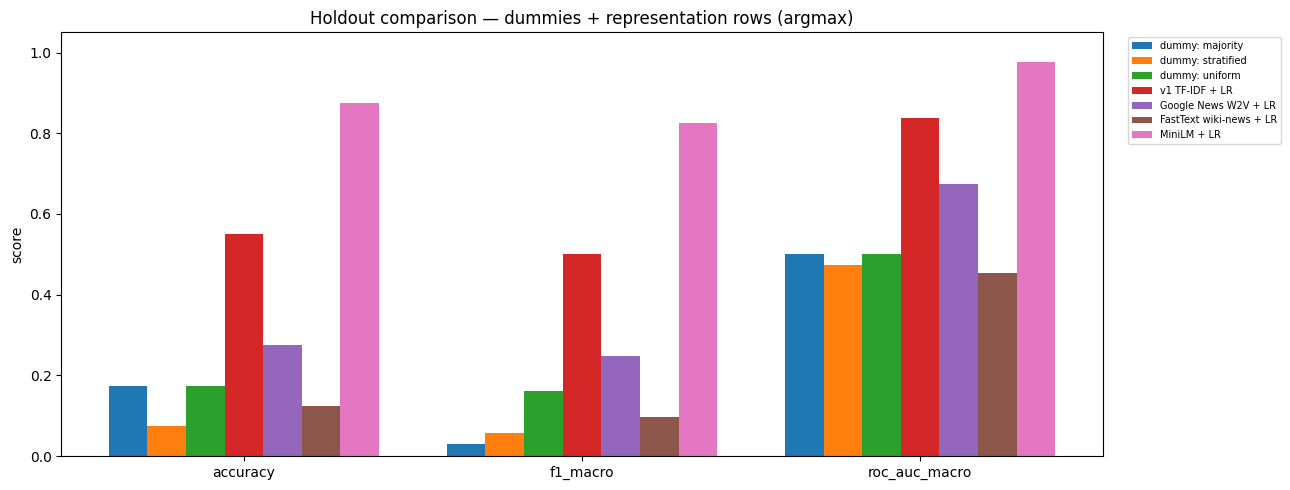

Best representation row: MiniLM + LR | holdout F1-macro: 0.8258


In [117]:
from sklearn.dummy import DummyClassifier

# Development / display order (not sorted by performance)
COMPARISON_ORDER = [
    "dummy: majority",
    "dummy: stratified",
    "dummy: uniform",
    "v1 TF-IDF + LR",
    "Google News W2V + LR",
    "FastText wiki-news + LR",
    "MiniLM + LR",
]

rows = [row_tfidf, row_w2v, row_ft, row_mlm]
holdout_rows = [eval_holdout(r) for r in rows]
for r in holdout_rows:
    r["row"] = normalize_row_name(r["row"])


def eval_dummy(name, strategy):
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_train, y_train)
    pred = dummy.predict(X_test)
    proba = dummy.predict_proba(X_test)
    classes = list(dummy.classes_)
    aligned = np.zeros((len(pred), len(CLASS_NAMES)))
    for j, cls in enumerate(CLASS_NAMES):
        if cls in classes:
            aligned[:, j] = proba[:, classes.index(cls)]
    return {
        "row": name,
        "best_C": np.nan,
        "cv_f1_macro": np.nan,
        "accuracy": accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, pred, average="weighted", zero_division=0),
        "roc_auc_macro": roc_auc_score(y_test, aligned, multi_class="ovr", average="macro", labels=CLASS_NAMES),
    }


dummy_rows = [
    eval_dummy("dummy: majority", "most_frequent"),
    eval_dummy("dummy: stratified", "stratified"),
    eval_dummy("dummy: uniform", "uniform"),
]

comparison_rows = dummy_rows + holdout_rows
comparison_df = (
    pd.DataFrame(comparison_rows)
    .set_index("row")
    .reindex(COMPARISON_ORDER)
    .reset_index()
)
missing = set(COMPARISON_ORDER) - set(comparison_df.dropna(subset=["f1_macro"])["row"])
if missing:
    raise KeyError(
        f"Missing comparison rows: {sorted(missing)}. "
        "Re-run sections 4–7 (row fits), then this cell."
    )

display(comparison_df.round(4))

# OOV summary for static embeddings
oov_summary = []
for label, row in [("Word2Vec", row_w2v), ("FastText", row_ft)]:
    stats = row.get("meta", {}).get("oov_stats", {})
    if stats:
        oov_summary.append({"encoder": label, **stats})
if oov_summary:
    display(pd.DataFrame(oov_summary).round(4))

# Barplot: dummies + all 4 rows, fixed order
plot_metrics = ["accuracy", "f1_macro", "roc_auc_macro"]
plot_df = comparison_df.set_index("row").loc[COMPARISON_ORDER, plot_metrics]

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(plot_metrics))
n = len(plot_df)
width = 0.8 / n
for i, (name, vals) in enumerate(plot_df.iterrows()):
    ax.bar(x + i * width, vals.values, width, label=name)
ax.set_xticks(x + width * (n - 1) / 2)
ax.set_xticklabels(plot_metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("score")
ax.set_title("Holdout comparison — dummies + representation rows (argmax)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=7)
plt.tight_layout()
plt.show()

# Best among representation rows only (exclude dummies)
model_df = comparison_df[~comparison_df["row"].str.startswith("dummy:")].dropna(subset=["f1_macro"])
best_row = model_df.loc[model_df["f1_macro"].idxmax()]
print("Best representation row:", best_row["row"], "| holdout F1-macro:", round(best_row["f1_macro"], 4))

holdout_df = model_df.copy()


## 9. Confusion matrices + OvR ROC (all 4 rows)


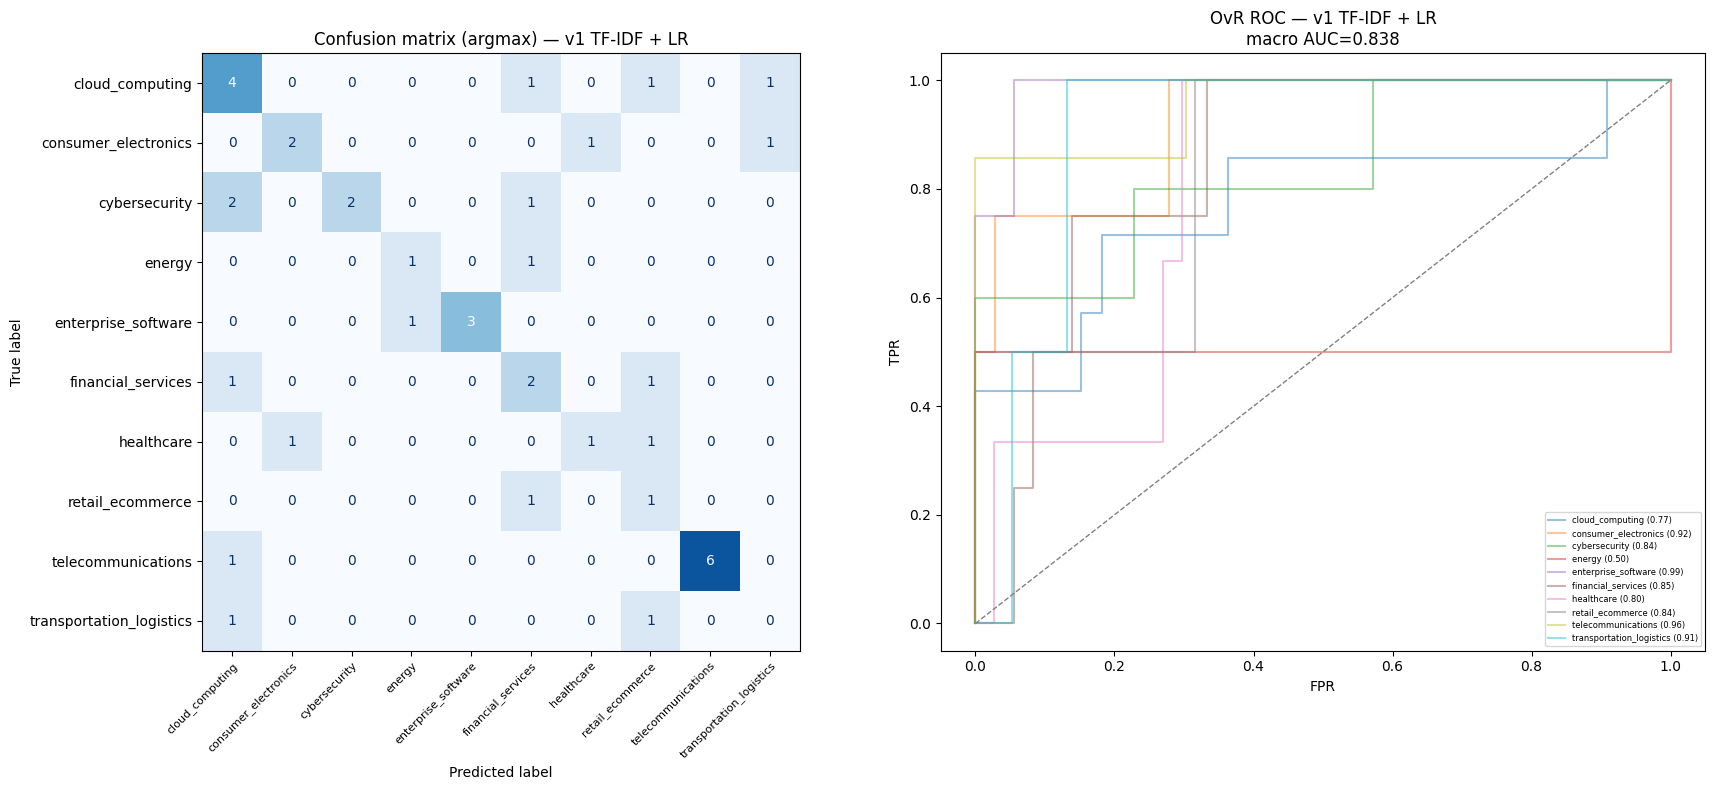

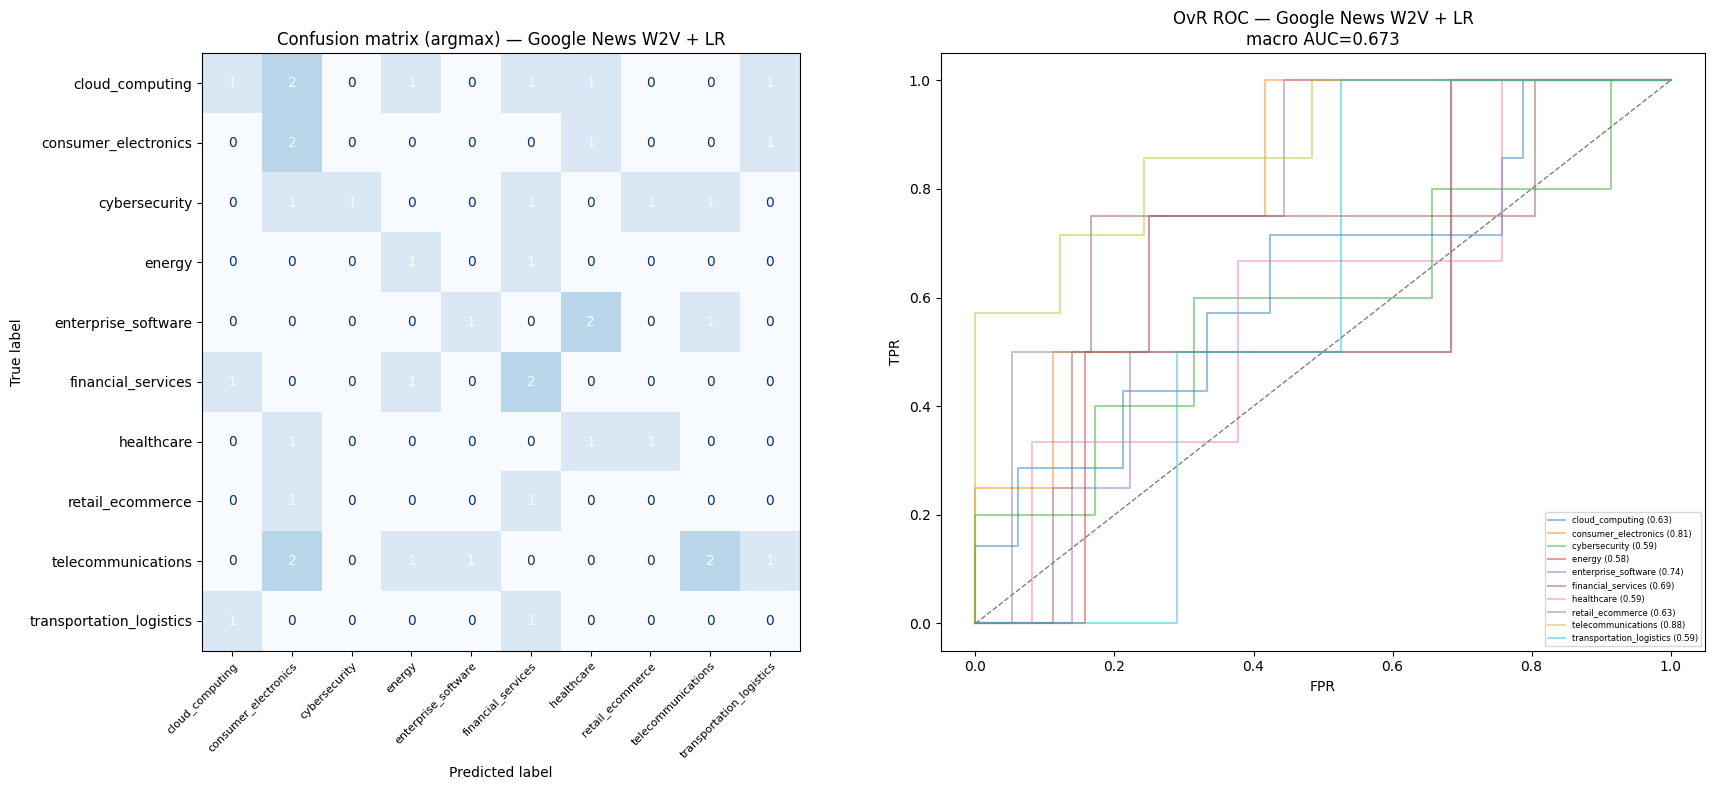

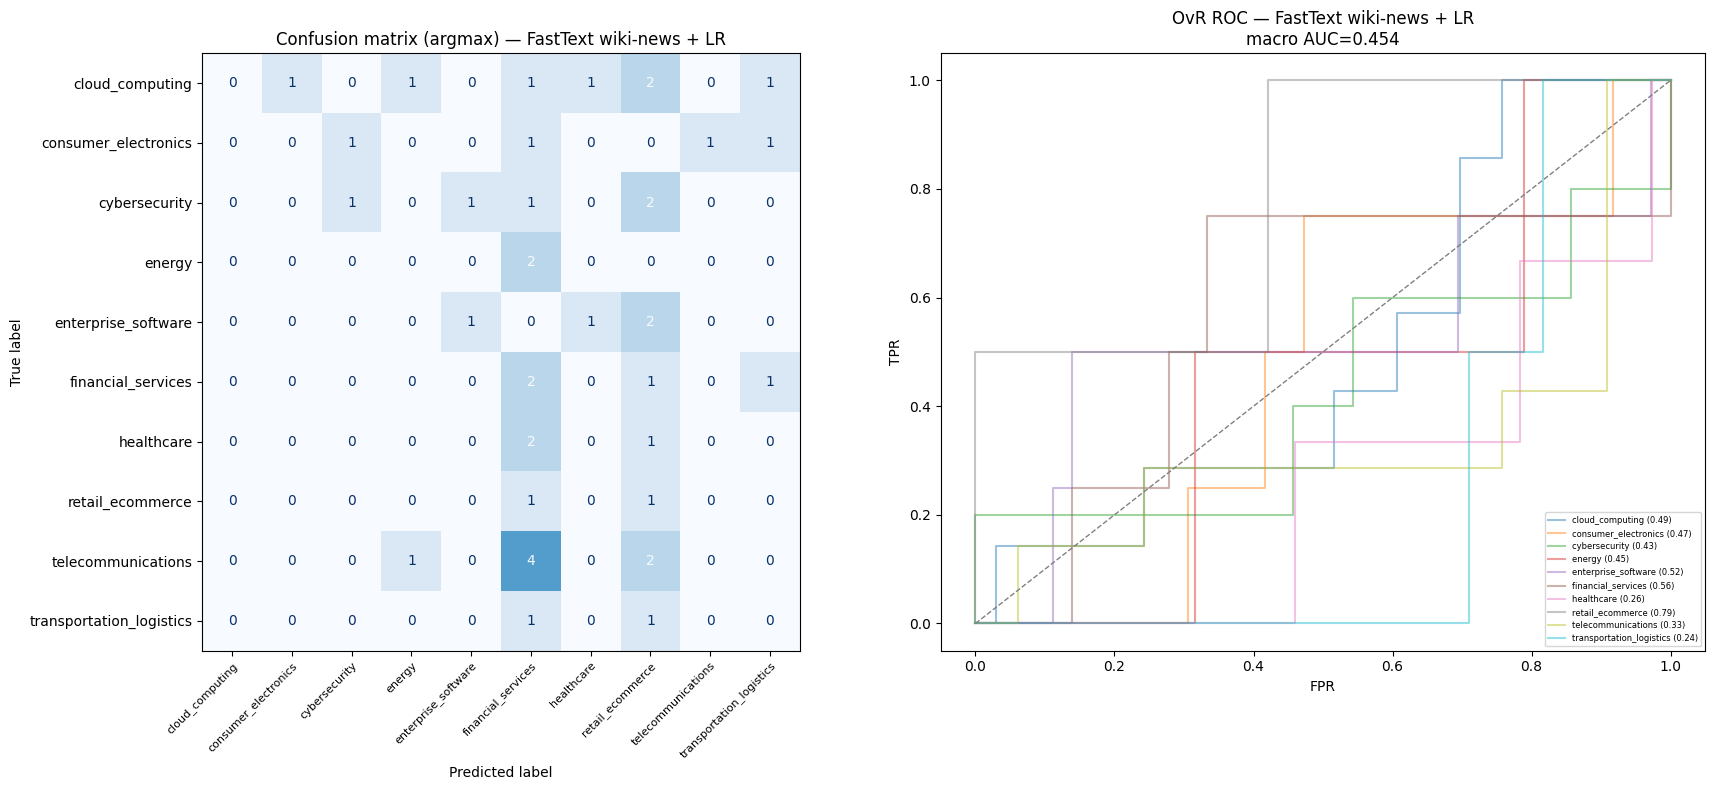

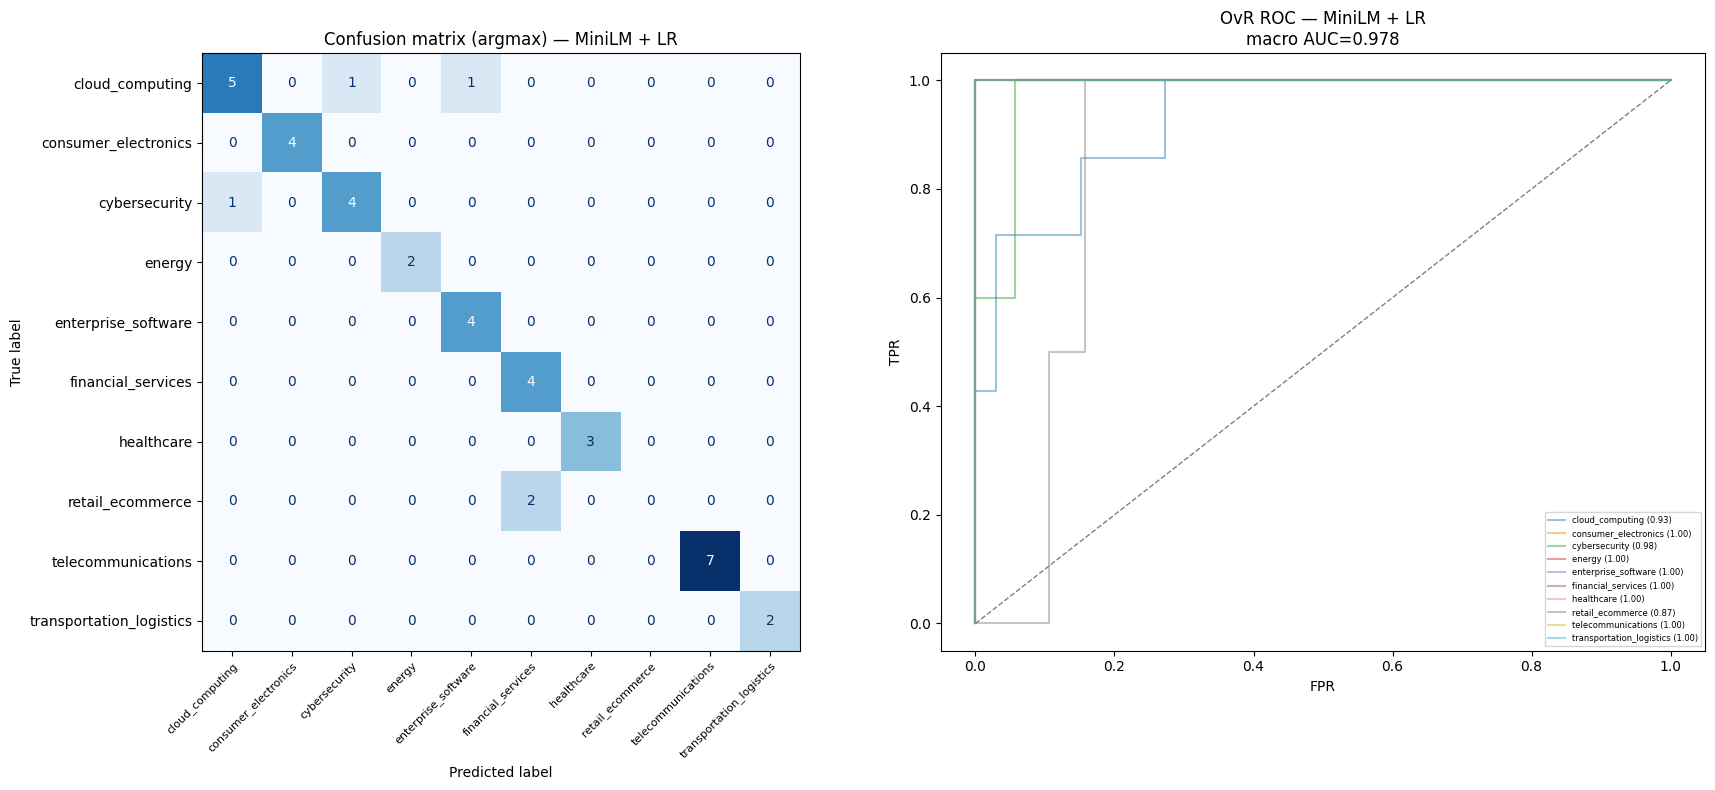

In [119]:
def _display_name(row: dict) -> str:
    return normalize_row_name(row["name"])

cms = {
    _display_name(row): confusion_matrix(y_test, row["pred"], labels=CLASS_NAMES)
    for row in rows
}
cm_vmax = max(int(cm.max()) for cm in cms.values())

for row in rows:
    name = _display_name(row)
    proba = row["proba"]
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    plot_cm_v1(
        axes[0],
        cms[name],
        f"Confusion matrix (argmax) — {name}",
        cm_vmax,
    )
    plot_ovr_roc(axes[1], y_test, proba, CLASS_NAMES, f"OvR ROC — {name}")

    plt.tight_layout()
    plt.show()


## 10. Feature contributions

Signed feature weights for all four rows. **Blue** = strongest positive class association, **orange** = opposite.

| row | what is plotted |
|-----|-----------------|
| TF-IDF | LR coef on TF-IDF tokens (same `tokenize()` as W2V/FastText) |
| W2V / FastText / MiniLM | `LR · word_vec × doc-IDF × sign(class association)` on corpus words |

Tokenizer keeps hyphenated terms whole (`e-commerce`, `cold-chain`). Ubiquitous or non-discriminative words are downweighted via doc-IDF and class-association filters.

**Caveat:** MiniLM encodes each corpus word in isolation (approximation). W2V skips OOV tokens; FastText uses subwords.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

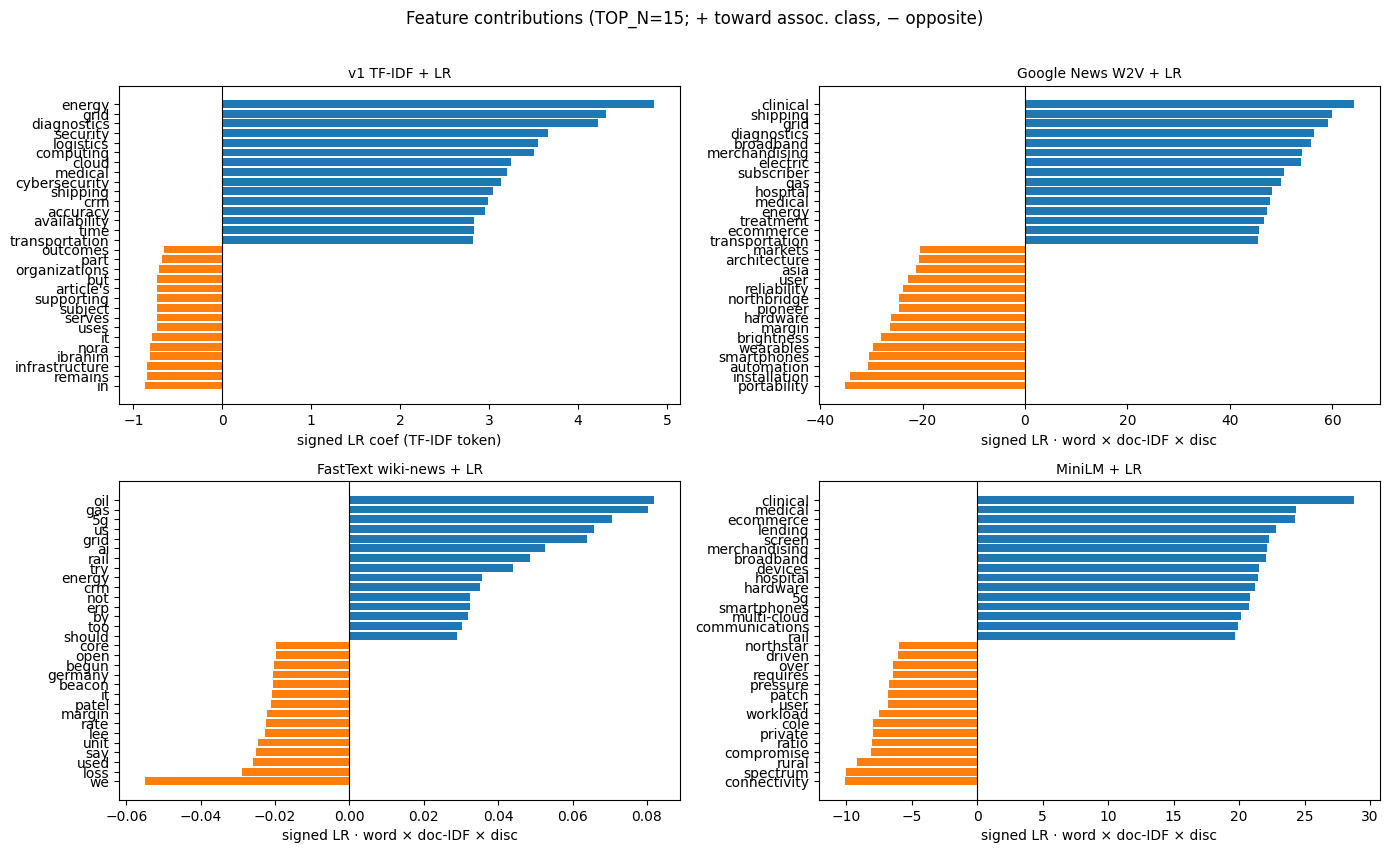

In [121]:
TOP_N = 15
WORD_VOCAB_MIN_DF = 2          # min document frequency
WORD_VOCAB_MAX = 5000
WORD_MAX_DOC_FRAC = 0.85        # skip words in >85% of train docs
WORD_MIN_DISC = 0.03            # min |class presence delta|
def _pick_signed_coef(coef: np.ndarray) -> np.ndarray:
    """One signed score per TF-IDF column from the class with the largest |weight|."""
    c = np.asarray(coef, dtype=float)
    if c.ndim == 1:
        return c
    return c[np.argmax(np.abs(c), axis=0), np.arange(c.shape[1])]


def _doc_token_sets(texts) -> list[set[str]]:
    return [set(tokenize(t)) for t in texts]


def _doc_vocab(texts, min_df: int = WORD_VOCAB_MIN_DF, max_words: int = WORD_VOCAB_MAX) -> tuple[list[str], dict[str, int]]:
    """Vocabulary + document frequencies (unique docs containing each word)."""
    from collections import Counter

    doc_freq = Counter()
    for doc_tokens in _doc_token_sets(texts):
        doc_freq.update(doc_tokens)
    words = [w for w, df in doc_freq.most_common() if df >= min_df]
    words = words[:max_words]
    return words, dict(doc_freq)


def _doc_idf(doc_freq: int, n_docs: int) -> float:
    return float(np.log((n_docs + 1) / (doc_freq + 1)) + 1)


def _word_discriminability(word: str, doc_sets: list[set[str]], y_ref) -> float:
    """Max over classes of |P(word | class) − P(word | other docs)|."""
    y_arr = np.asarray(y_ref)
    present = np.array([word in s for s in doc_sets], dtype=float)
    best = 0.0
    for c in np.unique(y_arr):
        m = y_arr == c
        delta = present[m].mean() - present[~m].mean()
        if abs(delta) > abs(best):
            best = delta
    return float(best)


def _signed_lr_projection(coef: np.ndarray, vec: np.ndarray) -> float:
    dots = np.asarray(coef, dtype=float) @ np.asarray(vec, dtype=float).ravel()
    i = int(np.argmax(np.abs(dots)))
    return float(dots[i])


def _embedding_word_scores(clf, texts, y_ref, lookup) -> tuple[np.ndarray, np.ndarray]:
    """Discriminative word scores for mean-pooled / sentence embedding + LR rows."""
    doc_sets = _doc_token_sets(texts)
    n_docs = len(texts)
    vocab, doc_freq_map = _doc_vocab(texts)
    names, scores = [], []
    for w in vocab:
        df = doc_freq_map[w]
        if df / n_docs > WORD_MAX_DOC_FRAC:
            continue
        disc = _word_discriminability(w, doc_sets, y_ref)
        if abs(disc) < WORD_MIN_DISC:
            continue
        vec = lookup(w)
        if vec is None:
            continue
        proj = _signed_lr_projection(clf.coef_, vec)
        score = proj * _doc_idf(df, n_docs) * np.sign(disc)
        names.append(w)
        scores.append(score)
    return np.array(names), np.asarray(scores, dtype=float)


def _word_scores_from_lookup(clf, texts, y_ref, lookup) -> tuple[np.ndarray, np.ndarray]:
    return _embedding_word_scores(clf, texts, y_ref, lookup)


def word_scores_w2v(clf, texts, y_ref) -> tuple[np.ndarray, np.ndarray]:
    from gensim.models import KeyedVectors

    path = EMBEDDINGS_DIR / W2V_FILENAME
    kv = KeyedVectors.load_word2vec_format(str(path), binary=True, limit=W2V_LOAD_LIMIT)
    vocab, _ = _doc_vocab(texts)
    try:
        return _word_scores_from_lookup(
            clf, texts, y_ref, lambda w: kv[w] if w in kv else None
        )
    finally:
        _free_memory(kv)


def word_scores_fasttext(clf, texts, y_ref) -> tuple[np.ndarray, np.ndarray]:
    from gensim.models import KeyedVectors

    path = EMBEDDINGS_DIR / FASTTEXT_FILENAME
    kv = KeyedVectors.load_word2vec_format(str(path))

    def lookup(w: str):
        if w in kv:
            return kv[w]
        try:
            return kv.get_vector(w)
        except Exception:
            return None

    try:
        return _word_scores_from_lookup(clf, texts, y_ref, lookup)
    finally:
        _free_memory(kv)


def word_scores_minilm(clf, texts, y_ref) -> tuple[np.ndarray, np.ndarray]:
    from sentence_transformers import SentenceTransformer

    doc_sets = _doc_token_sets(texts)
    n_docs = len(texts)
    vocab, doc_freq_map = _doc_vocab(texts)
    keep = []
    for w in vocab:
        df = doc_freq_map[w]
        if df / n_docs > WORD_MAX_DOC_FRAC:
            continue
        if abs(_word_discriminability(w, doc_sets, y_ref)) < WORD_MIN_DISC:
            continue
        keep.append(w)
    if not keep:
        return np.array([]), np.array([])

    model = SentenceTransformer(MINILM_MODEL_ID)
    try:
        embs = model.encode(
            list(keep),
            batch_size=64,
            show_progress_bar=len(keep) > 200,
            normalize_embeddings=True,
        )
        embs = np.asarray(embs, dtype=float)
        dots = embs @ clf.coef_.T
        idx = np.argmax(np.abs(dots), axis=1)
        proj = dots[np.arange(len(keep)), idx]
        idf = np.array([_doc_idf(doc_freq_map[w], n_docs) for w in keep], dtype=float)
        disc = np.array([_word_discriminability(w, doc_sets, y_ref) for w in keep], dtype=float)
        scores = proj * idf * np.sign(disc)
        return np.array(keep), scores
    finally:
        _free_memory(model)


def top_scores_for_row(row: dict):
    clf = row["clf"]
    key = row["key"]
    if key == "tfidf_v1":
        names = np.array(row["vectorizer"].get_feature_names_out())
        return names, _pick_signed_coef(clf.coef_)
    if key == "w2v":
        return word_scores_w2v(clf, X_train, y_train)
    if key == "fasttext":
        return word_scores_fasttext(clf, X_train, y_train)
    if key == "minilm":
        return word_scores_minilm(clf, X_train, y_train)
    return None, None


def plot_top_features(ax, title, names, scores, top_n=TOP_N, xlabel: str = "signed score"):
    if len(scores) == 0:
        ax.text(0.5, 0.5, f"No scorable features\n{title}", ha="center", va="center")
        ax.axis("off")
        return
    pos_idx = np.argsort(scores)[-top_n:]
    neg_idx = np.argsort(scores)[:top_n]
    idx = np.concatenate([neg_idx, pos_idx])
    seen = set()
    ordered = []
    for i in idx:
        if i not in seen:
            seen.add(i)
            ordered.append(i)
    idx = np.array(ordered)
    idx = idx[np.argsort(scores[idx])]
    colors = np.where(scores[idx] >= 0, "C0", "C1")
    ax.barh(names[idx], scores[idx], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)


plot_rows = [(_display_name(row), row) for row in rows]
ncols = 2
nrows = int(np.ceil(len(plot_rows) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

xlabels = {
    "tfidf_v1": "signed LR coef (TF-IDF token)",
    "w2v": "signed LR · word × doc-IDF × disc",
    "fasttext": "signed LR · word × doc-IDF × disc",
    "minilm": "signed LR · word × doc-IDF × disc",
}

for ax, (name, row) in zip(axes, plot_rows):
    feat_names, scores = top_scores_for_row(row)
    if scores is None:
        ax.text(0.5, 0.5, f"Unsupported row\n{name}", ha="center", va="center")
        ax.axis("off")
        continue
    plot_top_features(ax, name, feat_names, scores, xlabel=xlabels.get(row["key"], "signed score"))

for ax in axes[len(plot_rows):]:
    ax.axis("off")

fig.suptitle(
    f"Feature contributions (TOP_N={TOP_N}; + toward assoc. class, − opposite)",
    y=1.01,
)
plt.tight_layout()
plt.show()


## Save trained model


In [123]:
import joblib

winner_name = holdout_df.loc[holdout_df["f1_macro"].idxmax(), "row"]
winner_row = next(r for r in rows if normalize_row_name(r["name"]) == winner_name)

MODELS_DIR = DATA_PATH.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "ml_multi_v3.joblib"

if winner_row["key"] == "tfidf_v1":
    joblib.dump(winner_row["model"], MODEL_PATH)
else:
    artifact = {
        "name": winner_name,
        "key": winner_row["key"],
        "clf": winner_row["clf"],
        "classes": list(winner_row["clf"].classes_),
        "meta": winner_row.get("meta", {}),
    }
    joblib.dump(artifact, MODEL_PATH)

print("Winner:", winner_name)
print("saved:", MODEL_PATH.resolve())
print("reload: loaded = joblib.load(MODEL_PATH)")


Winner: MiniLM + LR
saved: /Users/jianchenyang/Documents/projects/file_topic_routing/data/models/ml_multi_v3.joblib
reload: loaded = joblib.load(MODEL_PATH)


## Notes / next steps

- **multi_v2** (planned): TF-IDF classifier bake-off — orthogonal to this notebook
- **multi_v4** (conditional): best embedding + reduced classifier bake-off only if v2 and v3 both beat v1 clearly
- Grow data before treating holdout rankings as production decisions
- Binary routing embeddings: defer unless routing needs them
